# Importing MESA Models and Visualizing Reactive Flow

We can visualize the reactive flow through [MESA stellar evolution models](https://docs.mesastar.org) by reconstructing the network and using pynucastro's machinery
to evaluate the rates.

We leverage [mesa_reader](https://github.com/wmwolf/py_mesa_reader) for loading the MESA data.

In [1]:
import mesa_reader as mr

We'll start with a MESA model for a classical nova.  This is from the MESA test suite (`$MESA_DIR/star/test_suite/wd_nova_burst`.  We'll use the model file closest to 
peak luminosity.

In [2]:
model = mr.MesaData("mesa_nova_profile8.data")

## `mesa_utils`

The pynucastro {py:mod}`mesa_utils <pynucastro.mesa_utils>` module will read in the data and convert it to pynucastro types.

In [3]:
from pynucastro import mesa_utils
import pynucastro as pyna

In [4]:
mesa_zones = mesa_utils.MesaModel(model)

We can use the methods in {py:obj}`MesaModel <pynucastro.mesa_utils.MesaModel>` to
access the data in various ways.

For example, we can get the zone corresponding to peak temperature:

In [5]:
idx = mesa_zones.get_peak_index("T")
idx

np.int64(570)

## Reproducing the network

MESA has many different reaction networks, which often have different rate approximations.
We could just find all of the nuclei used in the simulation, via:

In [6]:
nuclei = mesa_utils.get_nuclei(model)

and then build a network using {py:meth}`network_helper <pynucastro.networks.helper.network_helper>`, but that will not automatically reproduce the approximations, if any were used.

From within a MESA simulation, you can output all of the reaction rates used by adding:

```
show_net_reactions_info = .true.
```

to the `&star_job` inline.

In our case, the nova run was built using the `cno_extras_o18_to_mg26_plus_fe56.net` network.  This is essentially our {py:obj}`cno <pynucastro.networks.common_networks.cno>` networks with the addition of ${}^{22}\mathrm{Ne}$ and ${}^{26}\mathrm{Mg}$.  So we can build the network from there.

In [7]:
net = pyna.common_networks.cno()

In [8]:
rl = pyna.ReacLibLibrary()
ro18ag = rl.get_rate_by_name("o18(a,g)ne22")
rne22ag = rl.get_rate_by_name("ne22(a,g)mg26")

In [9]:
net.add_rates([ro18ag, rne22ag])

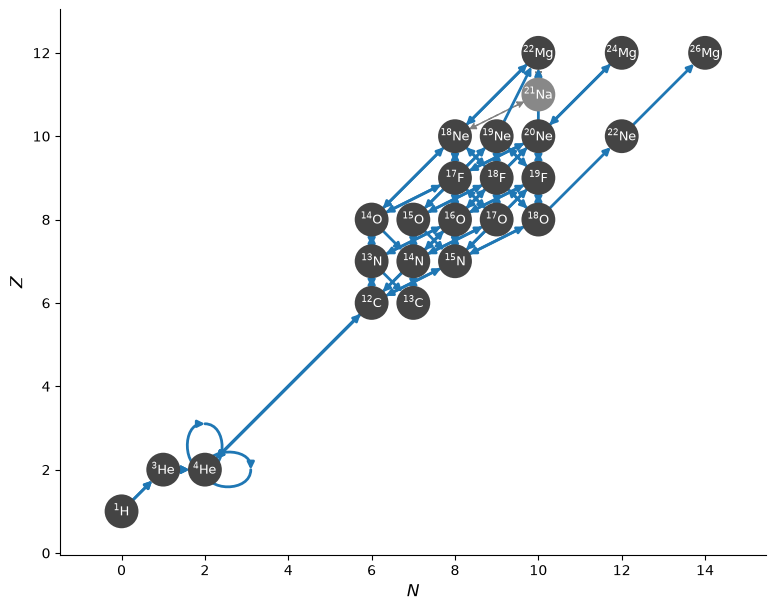

In [10]:
fig = net.plot(node_size=500, node_font_size="9",
               always_show_p=True)

## Visualizing the reactive flow

We can use {py:meth}`MesaModel.get_zone_data <pynucastro.mesa_utils.MesaModel.get_zone_data>`
to get the data corresponding to a single MESA zone (it will be returned as a {py:obj}`MesaZoneState <pynucastro.mesa_utils.MesaZoneState>` object.

We'll use the index corresponding to peak $T$ that we found above.

In [11]:
state = mesa_zones.get_zone_data(idx)

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N14 partition function is not supported by tables: set log_pf = 0.0 b

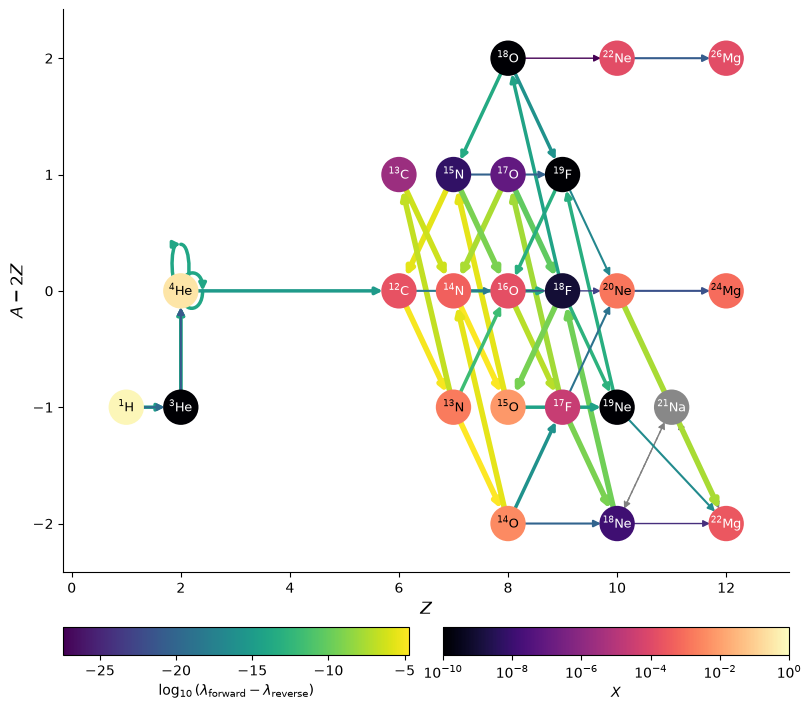

In [13]:
fig = net.plot(state.rho, state.T, state.comp,
               always_show_p=True,
               rotated=True,
               use_net_rate=True,
               size=(800, 700),
               node_size=550, node_font_size=9,
               color_nodes_by_abundance=True)